In [1]:
import os 
import glob 
from analysis.utils import *
import sys 
from utils import *
from easydict import EasyDict
from data import load_dataset_1d, load_dataset_2d
from inference import load_model, load_dataset, inference, vis1d_sample_result, vis2d_sample_result

In [2]:
log_root = './logs/exp1d'
weight_nms = [x[:-3] for x in glob.glob('./logs/exp1d/*/*/*100.pth')]
log_nms = [x[:-3] for x in glob.glob('./logs/exp1d/*/*/*100.csv')]

# log_root = './logs/exp2d'
# weight_nms = [x[:-3] for x in glob.glob('./logs/exp2d/*/*/*100.pth')]
# log_nms = [x[:-3] for x in glob.glob('./logs/exp2d/*/*/*100.csv')]

dataset_path = '/workdir/pde_data/'
valid_nms = list(set(weight_nms).intersection(set(log_nms)))

weight_paths = [x+'pth' for x in valid_nms]
log_paths = [x+'csv' for x in valid_nms]

In [3]:
log_df = load_accuracy_log(log_paths)

100%|██████████| 692/692 [00:01<00:00, 353.76it/s]


In [4]:
log_df[(log_df.model == 'ft1d') & (log_df.resolution == 4096)].sort_values(['model', 'dataset', 'coarse_level', 'resolution', 'residual']).head(20)

,model,dataset,coarse_level,resolution,residual,seed,test_l2,mcode


In [5]:
device = torch.device('cuda:1')

In [6]:
# test_dataset, u_normalizer = load_dataset(dataset_path, 'burgers', 1000, 200, sub=2)
test_dataset, u_normalizer = load_dataset(dataset_path, 'darcy', 1000, 100, sub=3)

load model :  gt2d-h4-w64-141-141-cl1-mlx-seed100.pth
load model :  gt2d-h4-w64-141-141-cl1-ml0-seed100.pth
load model :  gt2d-h4-w64-141-141-cl1-ml1-seed100.pth
load model :  gt2d-h4-w64-141-141-cl1-ml2-seed100.pth
load model :  gt2d-h4-w64-141-141-cl1-ml3-seed100.pth
load model :  gt2d-h4-w64-141-141-cl2-mlx-seed100.pth
load model :  gt2d-h4-w64-141-141-cl2-ml0-seed100.pth
load model :  gt2d-h4-w64-141-141-cl2-ml1-seed100.pth
load model :  gt2d-h4-w64-141-141-cl2-ml2-seed100.pth
load model :  gt2d-h4-w64-141-141-cl2-ml3-seed100.pth


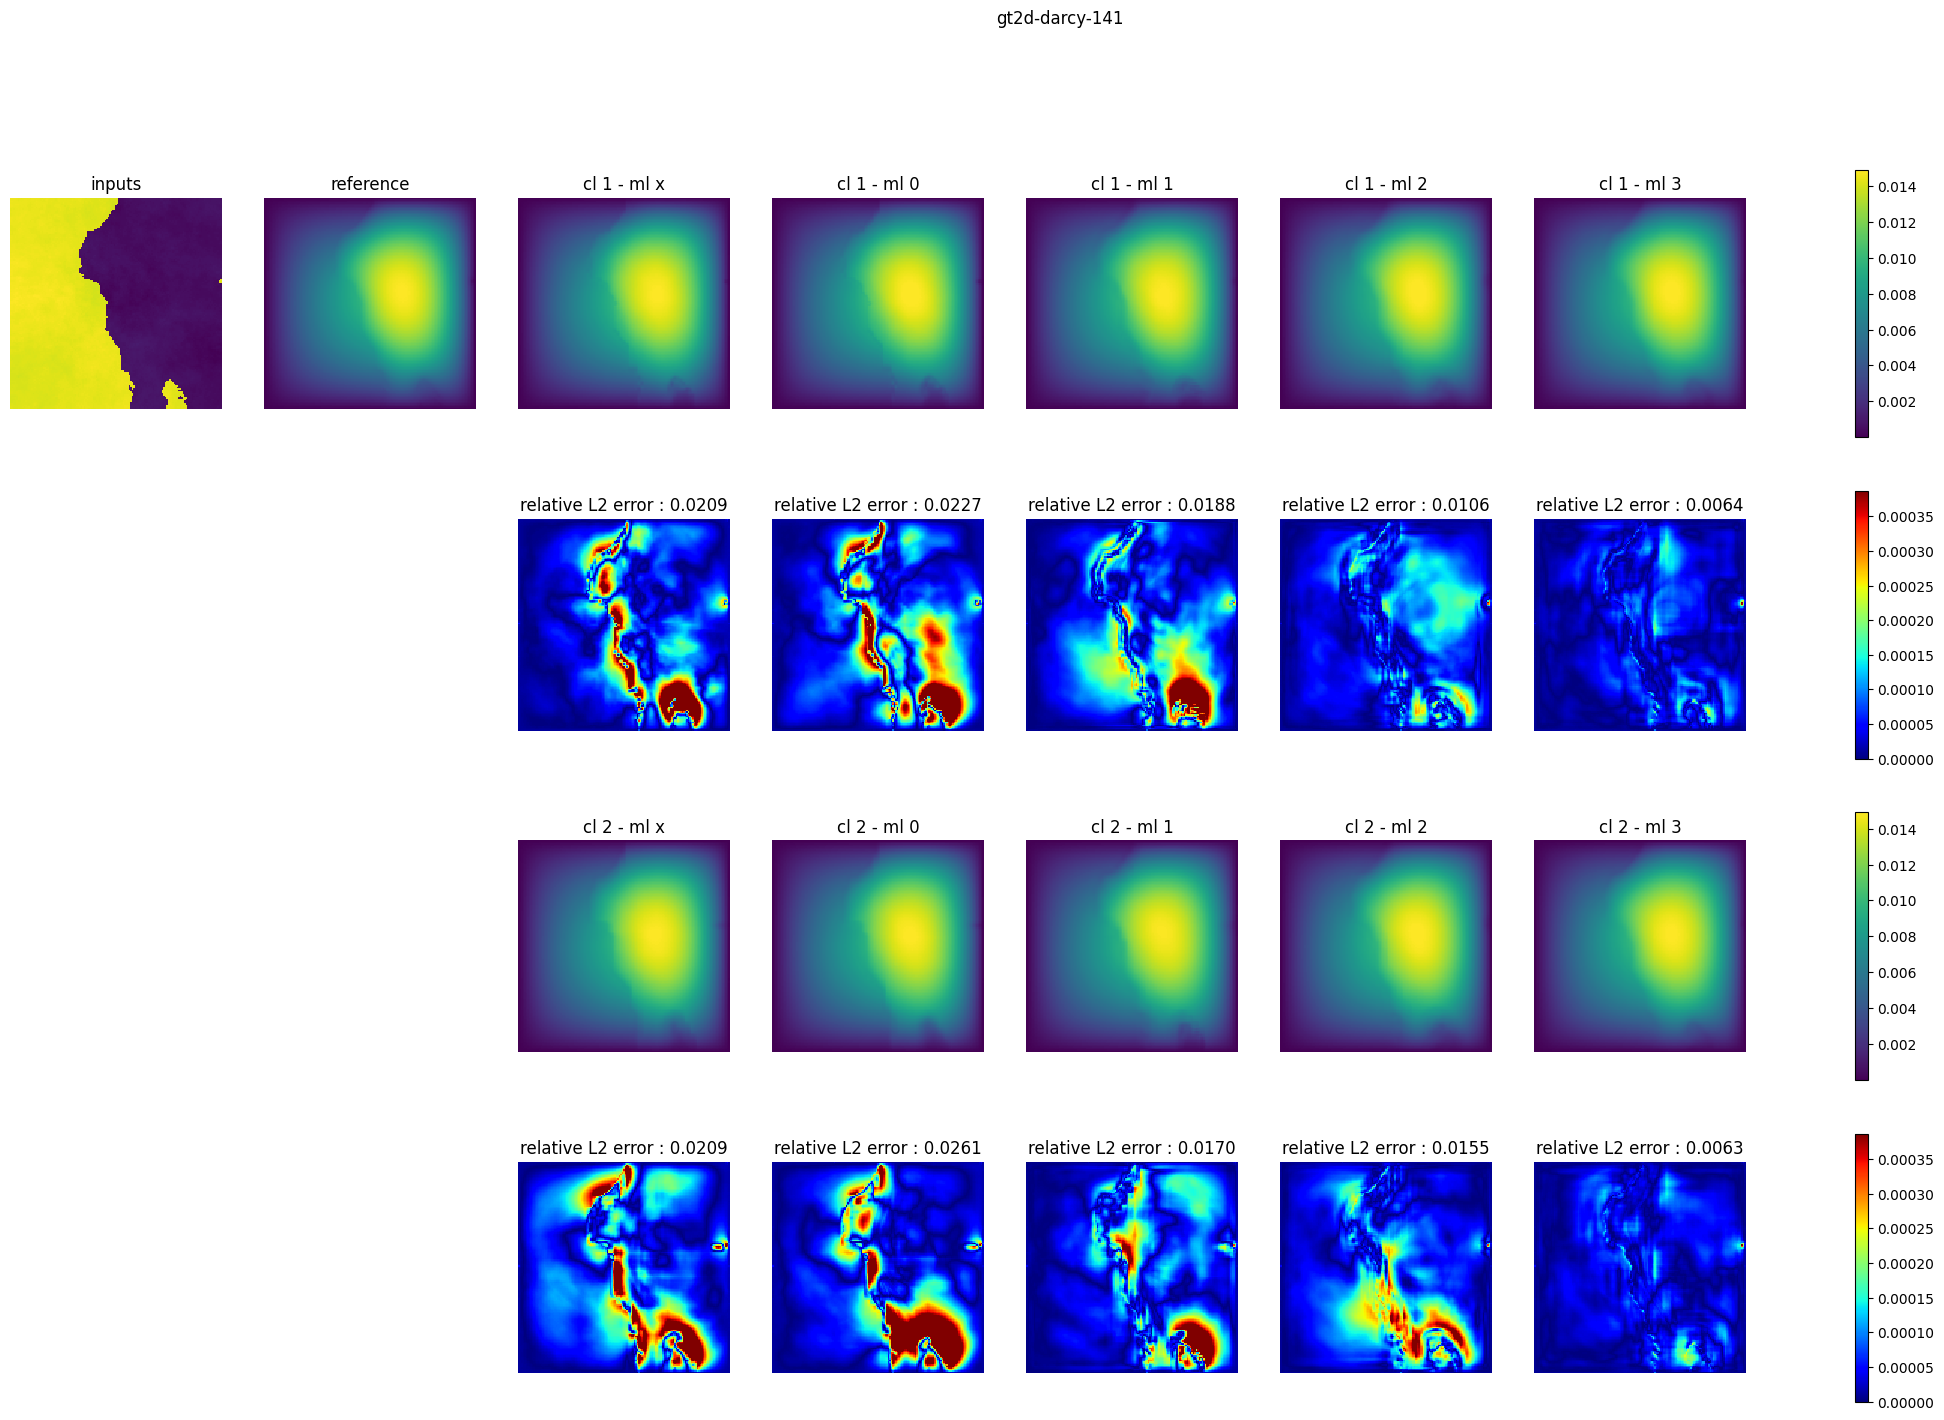

In [7]:
fig = vis2d_sample_result(10, test_dataset, u_normalizer, log_root, 'gt2d', 'darcy', [1, 2], ['x', 0, 1, 2, 3], device, sub=3)

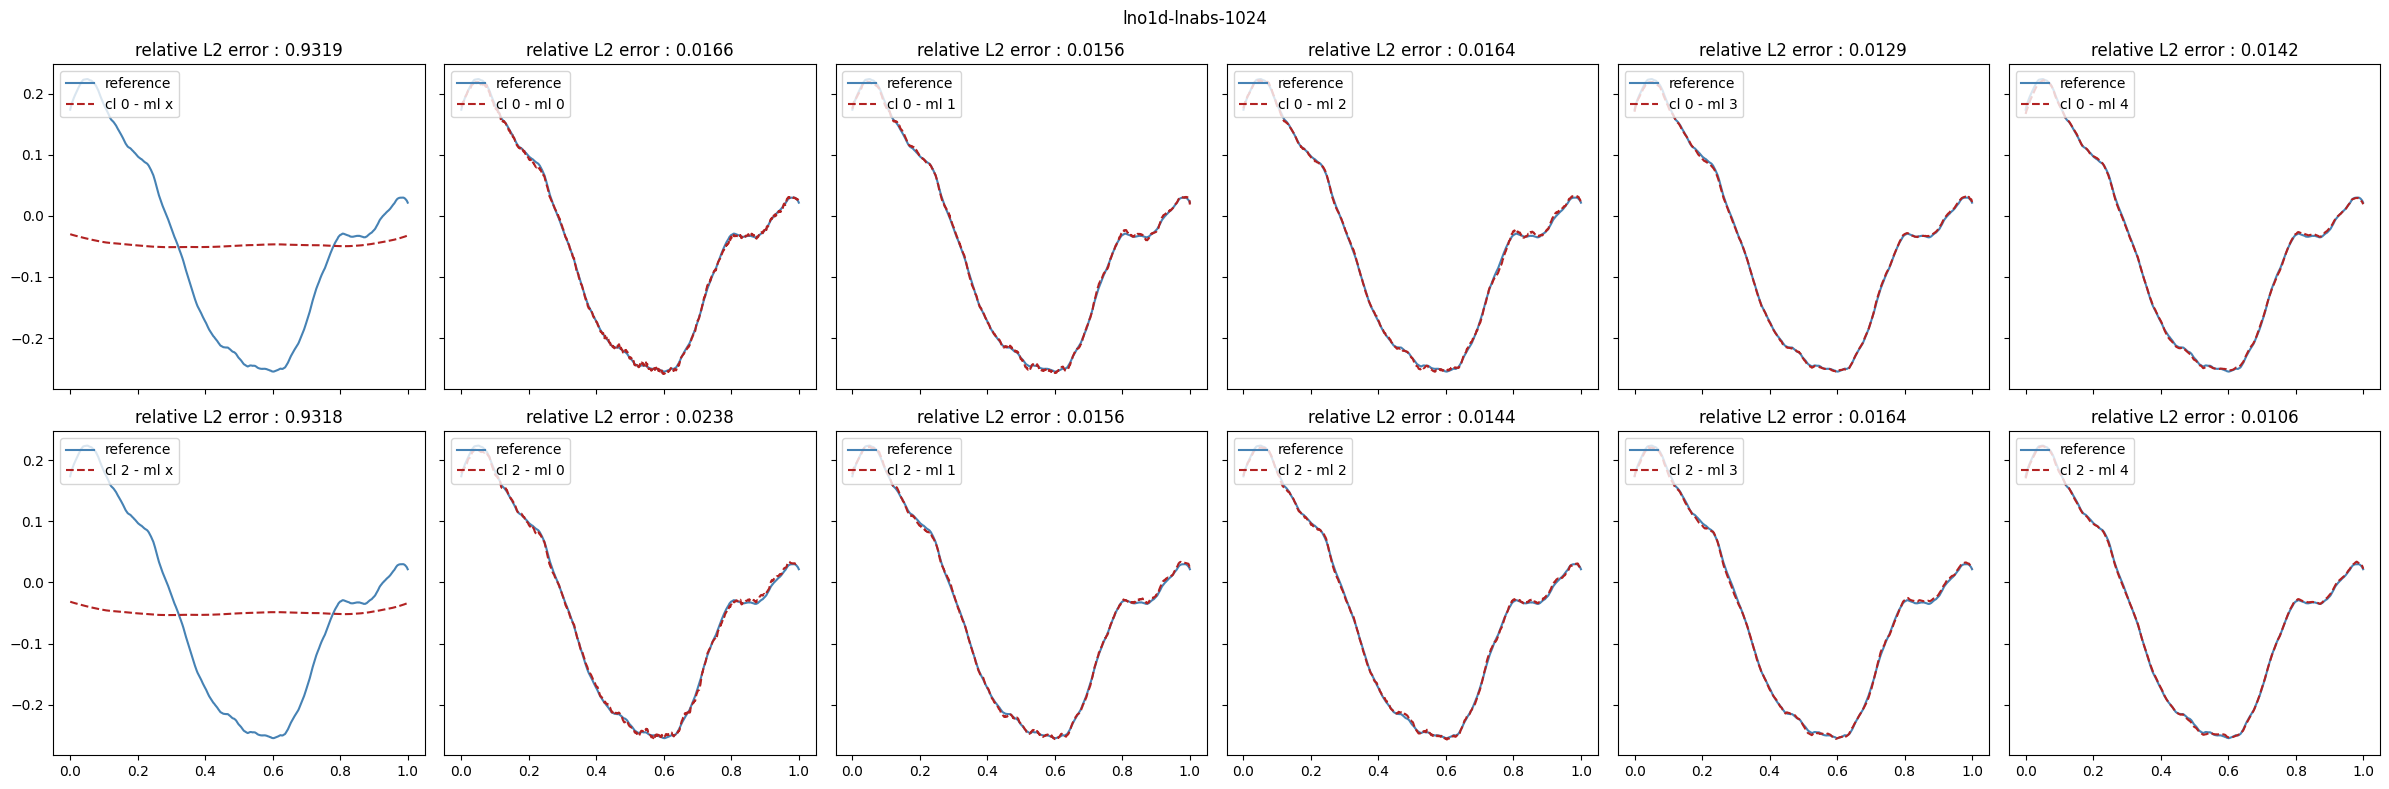

In [7]:
# fig = vis1d_sample_result(10, test_dataset, u_normalizer, log_root, 'lno1d', 'lnabs', [0, 2], ['x', 0, 1, 2, 3, 4], device, sub=8)